# 10 Structured Financial Data

## Goal

This notebook adds structured SEC XBRL financial data to RiskRadar AI.

So far, the project has focused on unstructured filing text.

Now we add financial metrics such as:

```text
Revenue
Net income
Assets
Liabilities
Operating cash flow
Stockholders' equity
```

The workflow is:

```text
company universe
→ SEC Company Facts API
→ extract financial concepts
→ build financial metrics table
→ calculate ratios
→ save structured financial dataset
```

This gives the project both:

```text
unstructured SEC text
+ structured SEC financial data
```

In [1]:
# Import tools for file and folder paths
from pathlib import Path

# Import time so we can pause between SEC requests
import time

# Import json for saving and inspecting API responses
import json

# Import pandas for tabular data work
import pandas as pd

# Import numpy for numerical calculations
import numpy as np

# Import requests for SEC API calls
import requests

# Import matplotlib for simple charts
import matplotlib.pyplot as plt

In [2]:
# Detect the project root automatically
# If this notebook is inside the notebooks folder, move one level up
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Create main project paths
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"

# Create SEC financial data folders
SEC_FINANCIAL_RAW_DIR = RAW_DIR / "sec_company_facts"
SEC_FINANCIAL_RAW_DIR.mkdir(parents=True, exist_ok=True)

# Create reports folder if needed
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Print paths to confirm everything is correct
print("Project root:", PROJECT_ROOT)
print("SEC financial raw folder:", SEC_FINANCIAL_RAW_DIR)
print("Processed data folder:", PROCESSED_DIR)
print("Reports folder:", REPORTS_DIR)

Project root: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI
SEC financial raw folder: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\data\raw\sec_company_facts
Processed data folder: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\data\processed
Reports folder: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\reports


#### SEC headers

In [3]:
# Create SEC request headers
# Use your project name and email so requests are identifiable
SEC_HEADERS = {
    "User-Agent": "RiskRadarAI/0.1 tevinswright@gmail.com",
    "Accept-Encoding": "gzip, deflate"
}

# Display headers
SEC_HEADERS

{'User-Agent': 'RiskRadarAI/0.1 tevinswright@gmail.com',
 'Accept-Encoding': 'gzip, deflate'}

#### Load company universe

In [4]:
# Set path to company universe created earlier
company_file = PROCESSED_DIR / "company_universe_with_cik.csv"

# Check that company universe exists
if not company_file.exists():
    raise FileNotFoundError(
        f"Could not find {company_file}. Run 00_project_intro.ipynb first."
    )

# Load company universe
company_universe = pd.read_csv(company_file)

# Standardize ticker values
company_universe["ticker"] = company_universe["ticker"].str.upper()

# Convert CIK to 10-digit padded CIK string for SEC API
company_universe["cik_padded"] = (
    company_universe["cik"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.strip()
    .str.zfill(10)
)

# Preview company universe
company_universe

,ticker,company_name,sector,cik,cik_padded,company_title
0,NVDA,NVIDIA,Semiconductors,1045810,0001045810,NVIDIA CORP
1,MSFT,Microsoft,Cloud / Software,789019,0000789019,MICROSOFT CORP
2,AAPL,Apple,Consumer Technology,320193,0000320193,Apple Inc.
3,TSLA,Tesla,Electric Vehicles,1318605,0001318605,"Tesla, Inc."
4,AMZN,Amazon,E-Commerce / Cloud,1018724,0001018724,AMAZON COM INC
5,META,Meta Platforms,Social Media / AI,1326801,0001326801,"Meta Platforms, Inc."
6,AMD,Advanced Micro Devices,Semiconductors,2488,0000002488,ADVANCED MICRO DEVICES INC
7,PLTR,Palantir,Data / AI Software,1321655,0001321655,Palantir Technologies Inc.
8,JPM,JPMorgan Chase,Banking,19617,0000019617,JPMORGAN CHASE & CO
9,UNH,UnitedHealth Group,Healthcare,731766,0000731766,UNITEDHEALTH GROUP INC


#### Select companies in current vector database

In [5]:
# Set path to final RAG chunks
rag_chunks_file = PROCESSED_DIR / "sec_10k_rag_chunks.csv"

# Check if RAG chunk file exists
if not rag_chunks_file.exists():
    raise FileNotFoundError(
        f"Could not find {rag_chunks_file}. Run 04_chunking_experiments.ipynb first."
    )

# Load RAG chunks to see which companies are currently in the system
rag_chunks_df = pd.read_csv(rag_chunks_file)

# Get available tickers from the RAG system
available_tickers = sorted(rag_chunks_df["ticker"].unique())

# Filter company universe to only companies already used in the RAG pipeline
financial_companies = company_universe[
    company_universe["ticker"].isin(available_tickers)
].copy()

# Sort for readability
financial_companies = financial_companies.sort_values("ticker").reset_index(drop=True)

# Display selected companies
financial_companies

,ticker,company_name,sector,cik,cik_padded,company_title
0,AAPL,Apple,Consumer Technology,320193,0000320193,Apple Inc.
1,AMD,Advanced Micro Devices,Semiconductors,2488,0000002488,ADVANCED MICRO DEVICES INC
2,MSFT,Microsoft,Cloud / Software,789019,0000789019,MICROSOFT CORP
3,NVDA,NVIDIA,Semiconductors,1045810,0001045810,NVIDIA CORP
4,TSLA,Tesla,Electric Vehicles,1318605,0001318605,"Tesla, Inc."


## SEC Company Facts API

The SEC Company Facts API returns company-level XBRL financial facts.

The endpoint pattern is:

```text
https://data.sec.gov/api/xbrl/companyfacts/CIK##########.json
```

Example:

```text
https://data.sec.gov/api/xbrl/companyfacts/CIK0001045810.json
```

The response contains accounting concepts such as revenue, assets, liabilities, equity, net income, and cash flow.

#### SEC company facts request function

In [6]:
def get_sec_company_facts(cik_padded, sleep_seconds=0.2):
    """
    Download SEC Company Facts JSON for one company.
    """

    # Build Company Facts API URL
    url = f"https://data.sec.gov/api/xbrl/companyfacts/CIK{cik_padded}.json"

    # Pause before request to respect SEC fair access expectations
    time.sleep(sleep_seconds)

    # Send request to SEC
    response = requests.get(
        url,
        headers=SEC_HEADERS,
        timeout=60
    )

    # Raise clear error if request fails
    if response.status_code != 200:
        raise Exception(
            f"SEC Company Facts request failed. Status: {response.status_code}. URL: {url}"
        )

    # Return JSON response
    return response.json()

Test one company facts request

In [7]:
# Select one company as a test
sample_company = financial_companies.iloc[0]

# Get sample ticker and CIK
sample_ticker = sample_company["ticker"]
sample_cik_padded = sample_company["cik_padded"]

# Download company facts JSON
sample_facts = get_sec_company_facts(sample_cik_padded)

# Print basic response details
print("Ticker:", sample_ticker)
print("Company name:", sample_facts.get("entityName"))
print("CIK:", sample_facts.get("cik"))
print("Top-level keys:", sample_facts.keys())
print("Fact groups:", sample_facts.get("facts", {}).keys())

Ticker: AAPL
Company name: Apple Inc.
CIK: 320193
Top-level keys: dict_keys(['cik', 'entityName', 'facts'])
Fact groups: dict_keys(['dei', 'us-gaap'])


Save raw sample facts

In [8]:
# Set output file path for sample company facts JSON
sample_facts_file = SEC_FINANCIAL_RAW_DIR / f"{sample_ticker}_companyfacts.json"

# Save raw JSON response locally
sample_facts_file.write_text(
    json.dumps(sample_facts, indent=2),
    encoding="utf-8"
)

# Confirm file was saved
print("Saved sample company facts to:", sample_facts_file)

Saved sample company facts to: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\data\raw\sec_company_facts\AAPL_companyfacts.json


Inspect available US-GAAP concepts

In [9]:
# Extract US-GAAP facts from sample response
sample_us_gaap = sample_facts.get("facts", {}).get("us-gaap", {})

# Get available concept names
sample_concepts = sorted(sample_us_gaap.keys())

# Print number of available concepts
print("Number of US-GAAP concepts:", len(sample_concepts))

# Preview first 50 concept names
sample_concepts[:50]

Number of US-GAAP concepts: 503


['AccountsPayable',
 'AccountsPayableCurrent',
 'AccountsReceivableNetCurrent',
 'AccruedIncomeTaxesCurrent',
 'AccruedIncomeTaxesNoncurrent',
 'AccruedLiabilities',
 'AccruedLiabilitiesCurrent',
 'AccruedMarketingCostsCurrent',
 'AccumulatedDepreciationDepletionAndAmortizationPropertyPlantAndEquipment',
 'AccumulatedOtherComprehensiveIncomeLossAvailableForSaleSecuritiesAdjustmentNetOfTax',
 'AccumulatedOtherComprehensiveIncomeLossCumulativeChangesInNetGainLossFromCashFlowHedgesEffectNetOfTax',
 'AccumulatedOtherComprehensiveIncomeLossForeignCurrencyTranslationAdjustmentNetOfTax',
 'AccumulatedOtherComprehensiveIncomeLossNetOfTax',
 'AdjustmentsToAdditionalPaidInCapitalSharebasedCompensationRequisiteServicePeriodRecognitionValue',
 'AdjustmentsToAdditionalPaidInCapitalTaxEffectFromShareBasedCompensation',
 'AdvertisingExpense',
 'AllocatedShareBasedCompensationExpense',
 'AllowanceForDoubtfulAccountsReceivableCurrent',
 'AmortizationOfIntangibleAssets',
 'AntidilutiveSecuritiesExcluded

Define target financial concepts

In [10]:
# Define financial concepts we want to extract
# Some companies use slightly different concept names, so we include alternatives
# The order matters: preferred concepts should come first
target_concepts = {
    "revenue": [
        "RevenueFromContractWithCustomerExcludingAssessedTax",
        "Revenues",
        "SalesRevenueNet"
    ],
    "net_income": [
        "NetIncomeLoss"
    ],
    "assets": [
        "Assets"
    ],
    "liabilities": [
        "Liabilities"
    ],
    "stockholders_equity": [
        "StockholdersEquity",
        "StockholdersEquityIncludingPortionAttributableToNoncontrollingInterest"
    ],
    "operating_cash_flow": [
        "NetCashProvidedByUsedInOperatingActivities"
    ],
    "cash_and_equivalents": [
        "CashAndCashEquivalentsAtCarryingValue",
        "CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents"
    ]
}

# These metrics are measured over a period of time
duration_metrics = {
    "revenue",
    "net_income",
    "operating_cash_flow"
}

# These metrics are measured at a point in time
instant_metrics = {
    "assets",
    "liabilities",
    "stockholders_equity",
    "cash_and_equivalents"
}

# Display target concepts
target_concepts

{'revenue': ['RevenueFromContractWithCustomerExcludingAssessedTax',
  'Revenues',
  'SalesRevenueNet'],
 'net_income': ['NetIncomeLoss'],
 'assets': ['Assets'],
 'liabilities': ['Liabilities'],
 'stockholders_equity': ['StockholdersEquity',
  'StockholdersEquityIncludingPortionAttributableToNoncontrollingInterest'],
 'operating_cash_flow': ['NetCashProvidedByUsedInOperatingActivities'],
 'cash_and_equivalents': ['CashAndCashEquivalentsAtCarryingValue',
  'CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents']}

Helper to extract concept units

In [11]:
def get_concept_units(company_facts_json, concept_name):
    """
    Get unit data for one US-GAAP concept from SEC Company Facts JSON.
    """

    # Get US-GAAP facts
    us_gaap_facts = company_facts_json.get("facts", {}).get("us-gaap", {})

    # Return None if concept is missing
    if concept_name not in us_gaap_facts:
        return None

    # Get concept data
    concept_data = us_gaap_facts[concept_name]

    # Get unit dictionary
    units = concept_data.get("units", {})

    # Return units
    return units

Helper to pick USD unit facts

In [12]:
def get_usd_facts_for_concept(company_facts_json, concept_name):
    """
    Extract USD facts for one accounting concept.

    Most financial statement values are stored under the USD unit.
    """

    # Get units for concept
    units = get_concept_units(company_facts_json, concept_name)

    # Return empty list if concept does not exist
    if units is None:
        return []

    # Prefer USD facts
    if "USD" in units:
        return units["USD"]

    # Some per-share concepts use USD/shares, but we are not using them here
    # Return empty list if USD is unavailable
    return []

Convert concept facts to DataFrame

In [13]:
def concept_facts_to_dataframe(company_facts_json, ticker, company_name, metric_name, concept_name):
    """
    Convert one SEC concept's facts into a DataFrame.
    """

    # Get USD facts for concept
    facts = get_usd_facts_for_concept(company_facts_json, concept_name)

    # Return empty DataFrame if there are no facts
    if len(facts) == 0:
        return pd.DataFrame()

    # Convert facts list to DataFrame
    facts_df = pd.DataFrame(facts)

    # Add project metadata
    facts_df["ticker"] = ticker
    facts_df["company_name"] = company_name
    facts_df["metric_name"] = metric_name
    facts_df["concept_name"] = concept_name

    # Return facts DataFrame
    return facts_df

Extract one metric with concept alternatives

In [14]:
def extract_metric_with_alternatives(company_facts_json, ticker, company_name, metric_name, concept_candidates):
    """
    Extract one metric using all available concept candidates.

    We keep all candidates at first, then later choose the best annual fact.
    This avoids missing revenue when the first concept exists but does not contain
    the best annual 10-K values.
    """

    # Create empty list to store candidate concept DataFrames
    candidate_frames = []

    # Loop through possible concept names
    for concept_priority, concept_name in enumerate(concept_candidates):

        # Convert concept facts to DataFrame
        concept_df = concept_facts_to_dataframe(
            company_facts_json=company_facts_json,
            ticker=ticker,
            company_name=company_name,
            metric_name=metric_name,
            concept_name=concept_name
        )

        # Store non-empty concept data
        if not concept_df.empty:

            # Add concept priority so preferred concepts can be selected later
            concept_df["concept_priority"] = concept_priority

            # Add concept data to list
            candidate_frames.append(concept_df)

    # Return empty DataFrame if no concept candidates were available
    if len(candidate_frames) == 0:
        return pd.DataFrame()

    # Combine all available concept candidates
    metric_df = pd.concat(candidate_frames, ignore_index=True)

    # Return combined metric data
    return metric_df

Extract target metrics for one company

In [15]:
def extract_target_metrics_for_company(company_facts_json, ticker, company_name, target_concepts):
    """
    Extract all target financial metrics for one company.
    """

    # Create empty list to store metric DataFrames
    metric_frames = []

    # Loop through each target metric
    for metric_name, concept_candidates in target_concepts.items():

        # Extract metric using concept alternatives
        metric_df = extract_metric_with_alternatives(
            company_facts_json=company_facts_json,
            ticker=ticker,
            company_name=company_name,
            metric_name=metric_name,
            concept_candidates=concept_candidates
        )

        # Add metric data if found
        if not metric_df.empty:
            metric_frames.append(metric_df)

    # Return empty DataFrame if no metrics were found
    if len(metric_frames) == 0:
        return pd.DataFrame()

    # Combine metric DataFrames
    company_metrics_df = pd.concat(metric_frames, ignore_index=True)

    # Return company metric data
    return company_metrics_df

Test extraction for one company

In [16]:
# Extract target metrics for sample company
sample_metrics_df = extract_target_metrics_for_company(
    company_facts_json=sample_facts,
    ticker=sample_ticker,
    company_name=sample_company["company_name"],
    target_concepts=target_concepts
)

# Preview sample metrics
sample_metrics_df[
    [
        "ticker",
        "metric_name",
        "concept_name",
        "fy",
        "fp",
        "form",
        "filed",
        "end",
        "val"
    ]
].head(20)

,ticker,metric_name,concept_name,fy,fp,form,filed,end,val
0,AAPL,revenue,RevenueFromContractWithCustomerExcludingAssess...,2019.0,FY,10-K,2019-10-31,2017-09-30,229234000000
1,AAPL,revenue,RevenueFromContractWithCustomerExcludingAssess...,2019.0,Q1,10-Q,2019-01-30,2017-12-30,88293000000
2,AAPL,revenue,RevenueFromContractWithCustomerExcludingAssess...,2019.0,FY,10-K,2019-10-31,2017-12-30,88293000000
3,AAPL,revenue,RevenueFromContractWithCustomerExcludingAssess...,2019.0,Q2,10-Q,2019-05-01,2018-03-31,149430000000
4,AAPL,revenue,RevenueFromContractWithCustomerExcludingAssess...,2019.0,Q2,10-Q,2019-05-01,2018-03-31,61137000000
5,AAPL,revenue,RevenueFromContractWithCustomerExcludingAssess...,2019.0,FY,10-K,2019-10-31,2018-03-31,61137000000
6,AAPL,revenue,RevenueFromContractWithCustomerExcludingAssess...,2019.0,Q3,10-Q,2019-07-31,2018-06-30,202695000000
7,AAPL,revenue,RevenueFromContractWithCustomerExcludingAssess...,2019.0,Q3,10-Q,2019-07-31,2018-06-30,53265000000
8,AAPL,revenue,RevenueFromContractWithCustomerExcludingAssess...,2019.0,FY,10-K,2019-10-31,2018-06-30,53265000000
9,AAPL,revenue,RevenueFromContractWithCustomerExcludingAssess...,2019.0,FY,10-K,2019-10-31,2018-09-29,265595000000


Download and extract metrics for all companies

In [17]:
# Create empty lists for raw responses and metric records
all_company_metrics = []
download_records = []

# Loop through each company
for _, row in financial_companies.iterrows():

    # Get company metadata
    ticker = row["ticker"]
    company_name = row["company_name"]
    cik_padded = row["cik_padded"]

    # Print progress
    print("Downloading company facts for:", ticker)

    # Download Company Facts JSON
    company_facts = get_sec_company_facts(cik_padded)

    # Save raw JSON locally
    raw_json_file = SEC_FINANCIAL_RAW_DIR / f"{ticker}_companyfacts.json"
    raw_json_file.write_text(
        json.dumps(company_facts, indent=2),
        encoding="utf-8"
    )

    # Extract target metrics
    company_metrics_df = extract_target_metrics_for_company(
        company_facts_json=company_facts,
        ticker=ticker,
        company_name=company_name,
        target_concepts=target_concepts
    )

    # Store metrics if available
    if not company_metrics_df.empty:
        all_company_metrics.append(company_metrics_df)

    # Store download record
    download_records.append({
        "ticker": ticker,
        "company_name": company_name,
        "cik_padded": cik_padded,
        "raw_json_file": str(raw_json_file),
        "metrics_found": len(company_metrics_df),
        "concepts_found": (
            company_metrics_df["concept_name"].nunique()
            if not company_metrics_df.empty else 0
        )
    })

# Combine all metric DataFrames
financial_facts_long_df = pd.concat(
    all_company_metrics,
    ignore_index=True
)

# Create download log
financial_download_log_df = pd.DataFrame(download_records)

# Display download log
financial_download_log_df

,ticker,company_name,cik_padded,raw_json_file,metrics_found,concepts_found
0,AAPL,Apple,0000320193,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,1686,10
1,AMD,Advanced Micro Devices,0000002488,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,1224,9
2,MSFT,Microsoft,0000789019,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,1725,10
3,NVDA,NVIDIA,0001045810,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,1568,9
4,TSLA,Tesla,0001318605,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,1485,10


Save raw financial facts long table

In [18]:
# Set output paths
financial_facts_long_file = PROCESSED_DIR / "sec_company_financial_facts_long.csv"
financial_download_log_file = PROCESSED_DIR / "sec_company_facts_download_log.csv"

# Save financial facts long table
financial_facts_long_df.to_csv(financial_facts_long_file, index=False)

# Save download log
financial_download_log_df.to_csv(financial_download_log_file, index=False)

# Confirm files were saved
print("Saved financial facts long table to:", financial_facts_long_file)
print("Saved financial download log to:", financial_download_log_file)

Saved financial facts long table to: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\data\processed\sec_company_financial_facts_long.csv
Saved financial download log to: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\data\processed\sec_company_facts_download_log.csv


Filter annual 10-K facts

In [19]:
# Create a clean copy of financial facts
annual_facts_df = financial_facts_long_df.copy()

# Keep only annual filing forms
annual_facts_df = annual_facts_df[
    annual_facts_df["form"].isin(["10-K", "10-K/A"])
].copy()

# Keep only rows with fiscal year values
annual_facts_df = annual_facts_df[annual_facts_df["fy"].notna()].copy()

# Convert fiscal year to integer
annual_facts_df["fy"] = annual_facts_df["fy"].astype(int)

# Keep recent fiscal years only
annual_facts_df = annual_facts_df[annual_facts_df["fy"] >= 2020].copy()

# Make sure expected date columns exist
for column in ["start", "end", "filed"]:
    if column not in annual_facts_df.columns:
        annual_facts_df[column] = pd.NaT

# Convert date columns
annual_facts_df["start_date"] = pd.to_datetime(
    annual_facts_df["start"],
    errors="coerce"
)

annual_facts_df["end_date"] = pd.to_datetime(
    annual_facts_df["end"],
    errors="coerce"
)

annual_facts_df["filed_date"] = pd.to_datetime(
    annual_facts_df["filed"],
    errors="coerce"
)

# Calculate period length for duration-based metrics
annual_facts_df["period_days"] = (
    annual_facts_df["end_date"] - annual_facts_df["start_date"]
).dt.days

# Make sure concept priority exists
if "concept_priority" not in annual_facts_df.columns:
    annual_facts_df["concept_priority"] = 99

# Duration metrics need full-year periods, not quarterly periods inside 10-K filings
duration_facts_df = annual_facts_df[
    annual_facts_df["metric_name"].isin(duration_metrics)
    & annual_facts_df["period_days"].between(300, 450)
].copy()

# Instant metrics are balance-sheet-style values measured at a point in time
instant_facts_df = annual_facts_df[
    annual_facts_df["metric_name"].isin(instant_metrics)
    & annual_facts_df["end_date"].notna()
].copy()

# Combine cleaned annual facts
annual_facts_df = pd.concat(
    [duration_facts_df, instant_facts_df],
    ignore_index=True
)

# Preview cleaned annual facts
annual_facts_df[
    [
        "ticker",
        "metric_name",
        "concept_name",
        "fy",
        "form",
        "filed",
        "start",
        "end",
        "period_days",
        "val"
    ]
].head(20)

,ticker,metric_name,concept_name,fy,form,filed,start,end,period_days,val
0,AAPL,revenue,RevenueFromContractWithCustomerExcludingAssess...,2020,10-K,2020-10-30,2017-10-01,2018-09-29,363.0,265595000000
1,AAPL,revenue,RevenueFromContractWithCustomerExcludingAssess...,2020,10-K,2020-10-30,2018-09-30,2019-09-28,363.0,260174000000
2,AAPL,revenue,RevenueFromContractWithCustomerExcludingAssess...,2021,10-K,2021-10-29,2018-09-30,2019-09-28,363.0,260174000000
3,AAPL,revenue,RevenueFromContractWithCustomerExcludingAssess...,2020,10-K,2020-10-30,2019-09-29,2020-09-26,363.0,274515000000
4,AAPL,revenue,RevenueFromContractWithCustomerExcludingAssess...,2021,10-K,2021-10-29,2019-09-29,2020-09-26,363.0,274515000000
5,AAPL,revenue,RevenueFromContractWithCustomerExcludingAssess...,2022,10-K,2022-10-28,2019-09-29,2020-09-26,363.0,274515000000
6,AAPL,revenue,RevenueFromContractWithCustomerExcludingAssess...,2021,10-K,2021-10-29,2020-09-27,2021-09-25,363.0,365817000000
7,AAPL,revenue,RevenueFromContractWithCustomerExcludingAssess...,2022,10-K,2022-10-28,2020-09-27,2021-09-25,363.0,365817000000
8,AAPL,revenue,RevenueFromContractWithCustomerExcludingAssess...,2023,10-K,2023-11-03,2020-09-27,2021-09-25,363.0,365817000000
9,AAPL,revenue,RevenueFromContractWithCustomerExcludingAssess...,2022,10-K,2022-10-28,2021-09-26,2022-09-24,363.0,394328000000


Keep latest filed fact per company, metric, year

In [20]:
# Sort facts so the best annual fact appears first
# Priority rules:
# 1. Preferred concept name
# 2. Latest filed date
# 3. Longest valid annual period
annual_facts_df = annual_facts_df.sort_values(
    ["ticker", "metric_name", "fy", "concept_priority", "filed_date", "period_days"],
    ascending=[True, True, True, True, False, False]
)

# Keep best row for each ticker, company, metric, and fiscal year
latest_annual_facts_df = (
    annual_facts_df
    .groupby(["ticker", "company_name", "metric_name", "fy"], as_index=False)
    .head(1)
    .copy()
)

# Preview latest annual facts
latest_annual_facts_df[
    [
        "ticker",
        "metric_name",
        "concept_name",
        "fy",
        "form",
        "filed",
        "period_days",
        "val"
    ]
].head(30)

,ticker,metric_name,concept_name,fy,form,filed,period_days,val
291,AAPL,assets,Assets,2020,10-K,2020-10-30,NaN,338516000000
293,AAPL,assets,Assets,2021,10-K,2021-10-29,NaN,323888000000
295,AAPL,assets,Assets,2022,10-K,2022-10-28,NaN,351002000000
297,AAPL,assets,Assets,2023,10-K,2023-11-03,NaN,352755000000
299,AAPL,assets,Assets,2024,10-K,2024-11-01,NaN,352583000000
301,AAPL,assets,Assets,2025,10-K,2025-10-31,NaN,364980000000
339,AAPL,cash_and_equivalents,CashAndCashEquivalentsAtCarryingValue,2020,10-K,2020-10-30,NaN,48844000000
341,AAPL,cash_and_equivalents,CashAndCashEquivalentsAtCarryingValue,2021,10-K,2021-10-29,NaN,38016000000
343,AAPL,cash_and_equivalents,CashAndCashEquivalentsAtCarryingValue,2022,10-K,2022-10-28,NaN,34940000000
345,AAPL,cash_and_equivalents,CashAndCashEquivalentsAtCarryingValue,2023,10-K,2023-11-03,NaN,23646000000


Pivot facts into financial metrics table

In [21]:
# Pivot financial facts from long format to wide format
financial_metrics_df = latest_annual_facts_df.pivot_table(
    index=["ticker", "company_name", "fy"],
    columns="metric_name",
    values="val",
    aggfunc="first"
).reset_index()

# Remove column index name
financial_metrics_df.columns.name = None

# Sort by ticker and fiscal year
financial_metrics_df = financial_metrics_df.sort_values(
    ["ticker", "fy"]
).reset_index(drop=True)

# Preview financial metrics table
financial_metrics_df

,ticker,company_name,fy,assets,cash_and_equivalents,liabilities,net_income,operating_cash_flow,revenue,stockholders_equity
0,AAPL,Apple,2020,3.385160e+11,4.884400e+10,2.480280e+11,5.953100e+10,7.743400e+10,2.655950e+11,1.340470e+11
1,AAPL,Apple,2021,3.238880e+11,3.801600e+10,2.585490e+11,5.525600e+10,6.939100e+10,2.601740e+11,1.071470e+11
2,AAPL,Apple,2022,3.510020e+11,3.494000e+10,2.879120e+11,5.741100e+10,8.067400e+10,2.745150e+11,9.048800e+10
3,AAPL,Apple,2023,3.527550e+11,2.364600e+10,3.020830e+11,9.699500e+10,1.105430e+11,3.832850e+11,6.533900e+10
4,AAPL,Apple,2024,3.525830e+11,2.996500e+10,2.904370e+11,9.699500e+10,1.105430e+11,3.832850e+11,6.309000e+10
5,AAPL,Apple,2025,3.649800e+11,2.994300e+10,3.080300e+11,9.699500e+10,1.105430e+11,3.832850e+11,5.067200e+10
6,AMD,Advanced Micro Devices,2020,6.028000e+09,1.078000e+09,NaN,3.370000e+08,3.400000e+07,6.475000e+09,1.266000e+09
7,AMD,Advanced Micro Devices,2021,8.962000e+09,1.466000e+09,NaN,3.410000e+08,4.930000e+08,6.731000e+09,2.827000e+09
8,AMD,Advanced Micro Devices,2022,1.241900e+10,2.535000e+09,NaN,1.320000e+09,3.565000e+09,2.360100e+10,5.837000e+09
9,AMD,Advanced Micro Devices,2023,6.758000e+10,4.835000e+09,NaN,1.320000e+09,3.565000e+09,2.360100e+10,7.497000e+09


Add financial ratios and growth metrics

In [22]:
# Create a copy for ratio calculations
financial_ratios_df = financial_metrics_df.copy()

# If liabilities are missing but assets and equity exist, estimate liabilities
# Basic accounting identity: Assets = Liabilities + Equity
if {"assets", "stockholders_equity"}.issubset(financial_ratios_df.columns):

    # Create liabilities column if missing
    if "liabilities" not in financial_ratios_df.columns:
        financial_ratios_df["liabilities"] = np.nan

    # Fill missing liabilities using assets minus stockholders' equity
    financial_ratios_df["liabilities"] = financial_ratios_df["liabilities"].fillna(
        financial_ratios_df["assets"] - financial_ratios_df["stockholders_equity"]
    )

# Calculate net margin if revenue and net income exist
if {"revenue", "net_income"}.issubset(financial_ratios_df.columns):
    financial_ratios_df["net_margin"] = (
        financial_ratios_df["net_income"] / financial_ratios_df["revenue"]
    )

# Calculate liabilities-to-assets ratio if liabilities and assets exist
if {"liabilities", "assets"}.issubset(financial_ratios_df.columns):
    financial_ratios_df["liabilities_to_assets"] = (
        financial_ratios_df["liabilities"] / financial_ratios_df["assets"]
    )

# Calculate return on assets if net income and assets exist
if {"net_income", "assets"}.issubset(financial_ratios_df.columns):
    financial_ratios_df["return_on_assets"] = (
        financial_ratios_df["net_income"] / financial_ratios_df["assets"]
    )

# Calculate revenue growth by company
if "revenue" in financial_ratios_df.columns:
    financial_ratios_df["revenue_growth"] = (
        financial_ratios_df
        .groupby("ticker")["revenue"]
        .pct_change(fill_method=None)
    )

# Calculate net income growth by company
if "net_income" in financial_ratios_df.columns:
    financial_ratios_df["net_income_growth"] = (
        financial_ratios_df
        .groupby("ticker")["net_income"]
        .pct_change(fill_method=None)
    )

# Preview ratio table
financial_ratios_df

,ticker,company_name,fy,assets,cash_and_equivalents,liabilities,net_income,operating_cash_flow,revenue,stockholders_equity,net_margin,liabilities_to_assets,return_on_assets,revenue_growth,net_income_growth
0,AAPL,Apple,2020,3.385160e+11,4.884400e+10,2.480280e+11,5.953100e+10,7.743400e+10,2.655950e+11,1.340470e+11,0.224142,0.732692,0.175859,NaN,NaN
1,AAPL,Apple,2021,3.238880e+11,3.801600e+10,2.585490e+11,5.525600e+10,6.939100e+10,2.601740e+11,1.071470e+11,0.212381,0.798267,0.170602,-0.020411,-0.071811
2,AAPL,Apple,2022,3.510020e+11,3.494000e+10,2.879120e+11,5.741100e+10,8.067400e+10,2.745150e+11,9.048800e+10,0.209136,0.820257,0.163563,0.055121,0.039000
3,AAPL,Apple,2023,3.527550e+11,2.364600e+10,3.020830e+11,9.699500e+10,1.105430e+11,3.832850e+11,6.533900e+10,0.253062,0.856354,0.274964,0.396226,0.689485
4,AAPL,Apple,2024,3.525830e+11,2.996500e+10,2.904370e+11,9.699500e+10,1.105430e+11,3.832850e+11,6.309000e+10,0.253062,0.823741,0.275098,0.000000,0.000000
5,AAPL,Apple,2025,3.649800e+11,2.994300e+10,3.080300e+11,9.699500e+10,1.105430e+11,3.832850e+11,5.067200e+10,0.253062,0.843964,0.265754,0.000000,0.000000
6,AMD,Advanced Micro Devices,2020,6.028000e+09,1.078000e+09,4.762000e+09,3.370000e+08,3.400000e+07,6.475000e+09,1.266000e+09,0.052046,0.789980,0.055906,NaN,NaN
7,AMD,Advanced Micro Devices,2021,8.962000e+09,1.466000e+09,6.135000e+09,3.410000e+08,4.930000e+08,6.731000e+09,2.827000e+09,0.050661,0.684557,0.038050,0.039537,0.011869
8,AMD,Advanced Micro Devices,2022,1.241900e+10,2.535000e+09,6.582000e+09,1.320000e+09,3.565000e+09,2.360100e+10,5.837000e+09,0.055930,0.529994,0.106289,2.506314,2.870968
9,AMD,Advanced Micro Devices,2023,6.758000e+10,4.835000e+09,6.008300e+10,1.320000e+09,3.565000e+09,2.360100e+10,7.497000e+09,0.055930,0.889065,0.019532,0.000000,0.000000


Format large numbers for display

In [23]:
def format_billions(value):
    """
    Format large dollar values in billions for display.
    """

    # Return blank for missing values
    if pd.isna(value):
        return ""

    # Convert to billions
    return round(value / 1_000_000_000, 2)


# Create a display table
financial_display_df = financial_ratios_df.copy()

# Format major dollar columns in billions if they exist
for column in ["revenue", "net_income", "assets", "liabilities", "operating_cash_flow"]:
    if column in financial_display_df.columns:
        financial_display_df[column + "_billions"] = financial_display_df[column].apply(format_billions)

# Preview display table
financial_display_df.head()

,ticker,company_name,fy,assets,cash_and_equivalents,liabilities,net_income,operating_cash_flow,revenue,stockholders_equity,net_margin,liabilities_to_assets,return_on_assets,revenue_growth,net_income_growth,revenue_billions,net_income_billions,assets_billions,liabilities_billions,operating_cash_flow_billions
0,AAPL,Apple,2020,3.385160e+11,4.884400e+10,2.480280e+11,5.953100e+10,7.743400e+10,2.655950e+11,1.340470e+11,0.224142,0.732692,0.175859,NaN,NaN,265.60,59.53,338.52,248.03,77.43
1,AAPL,Apple,2021,3.238880e+11,3.801600e+10,2.585490e+11,5.525600e+10,6.939100e+10,2.601740e+11,1.071470e+11,0.212381,0.798267,0.170602,-0.020411,-0.071811,260.17,55.26,323.89,258.55,69.39
2,AAPL,Apple,2022,3.510020e+11,3.494000e+10,2.879120e+11,5.741100e+10,8.067400e+10,2.745150e+11,9.048800e+10,0.209136,0.820257,0.163563,0.055121,0.039000,274.51,57.41,351.00,287.91,80.67
3,AAPL,Apple,2023,3.527550e+11,2.364600e+10,3.020830e+11,9.699500e+10,1.105430e+11,3.832850e+11,6.533900e+10,0.253062,0.856354,0.274964,0.396226,0.689485,383.29,97.00,352.75,302.08,110.54
4,AAPL,Apple,2024,3.525830e+11,2.996500e+10,2.904370e+11,9.699500e+10,1.105430e+11,3.832850e+11,6.309000e+10,0.253062,0.823741,0.275098,0.000000,0.000000,383.29,97.00,352.58,290.44,110.54


Latest year financial snapshot

In [24]:
# Get latest fiscal year per company
latest_year_by_ticker = (
    financial_ratios_df
    .groupby("ticker")["fy"]
    .max()
    .reset_index()
    .rename(columns={"fy": "latest_fy"})
)

# Merge latest year back to financial ratios
latest_financial_snapshot_df = financial_ratios_df.merge(
    latest_year_by_ticker,
    left_on=["ticker", "fy"],
    right_on=["ticker", "latest_fy"],
    how="inner"
)

# Drop helper column
latest_financial_snapshot_df = latest_financial_snapshot_df.drop(columns=["latest_fy"])

# Display latest snapshot
latest_financial_snapshot_df

,ticker,company_name,fy,assets,cash_and_equivalents,liabilities,net_income,operating_cash_flow,revenue,stockholders_equity,net_margin,liabilities_to_assets,return_on_assets,revenue_growth,net_income_growth
0,AAPL,Apple,2025,3.649800e+11,2.994300e+10,3.080300e+11,9.699500e+10,1.105430e+11,3.832850e+11,5.067200e+10,0.253062,0.843964,0.265754,0.000000,0.000000
1,AMD,Advanced Micro Devices,2025,6.922600e+10,3.933000e+09,1.333400e+10,8.540000e+08,1.667000e+09,2.268000e+10,5.589200e+10,0.037654,0.192615,0.012336,-0.039024,-0.353030
2,MSFT,Microsoft,2025,5.121630e+11,1.831500e+10,2.436860e+11,8.813600e+10,1.185480e+11,2.451220e+11,2.062230e+11,0.359560,0.475798,0.172086,0.000000,0.000000
3,NVDA,NVIDIA,2026,1.116010e+11,8.589000e+09,3.227400e+10,2.976000e+10,2.809000e+10,6.092200e+10,2.210100e+10,0.488493,0.289191,0.266664,1.258545,5.813187
4,TSLA,Tesla,2025,1.220700e+11,1.639800e+10,4.839000e+10,7.091000e+09,1.492300e+10,9.769000e+10,7.291300e+10,0.072587,0.396412,0.058090,0.000000,0.000000


Chart revenue by company

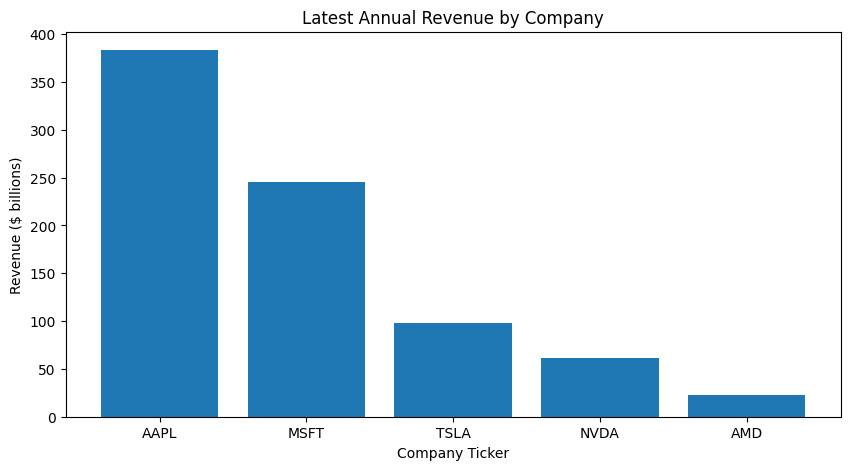

In [25]:
# Only create chart if revenue exists
if "revenue" in latest_financial_snapshot_df.columns:

    # Create chart data
    revenue_chart_df = latest_financial_snapshot_df.sort_values(
        "revenue",
        ascending=False
    )

    # Create bar chart
    plt.figure(figsize=(10, 5))

    # Plot revenue in billions
    plt.bar(
        revenue_chart_df["ticker"],
        revenue_chart_df["revenue"] / 1_000_000_000
    )

    # Add chart title and labels
    plt.title("Latest Annual Revenue by Company")
    plt.xlabel("Company Ticker")
    plt.ylabel("Revenue ($ billions)")

    # Display chart
    plt.show()

Chart net margin by company

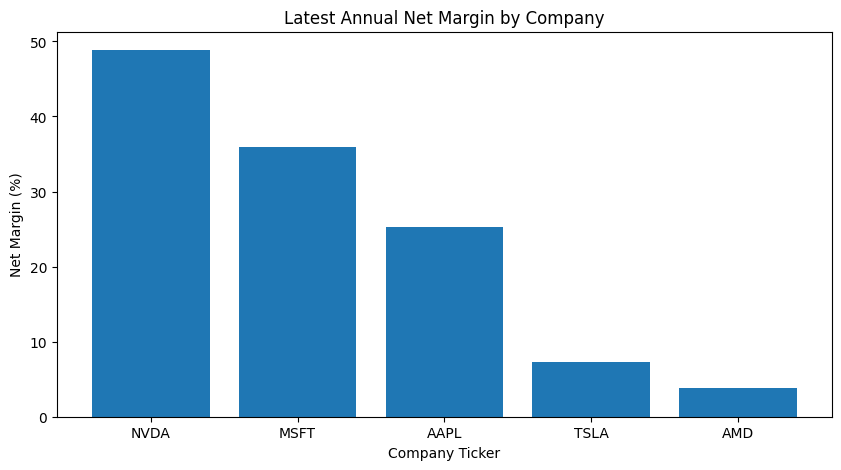

In [26]:
# Only create chart if net margin exists
if "net_margin" in latest_financial_snapshot_df.columns:

    # Create chart data
    margin_chart_df = latest_financial_snapshot_df.sort_values(
        "net_margin",
        ascending=False
    )

    # Create bar chart
    plt.figure(figsize=(10, 5))

    # Plot net margin percentage
    plt.bar(
        margin_chart_df["ticker"],
        margin_chart_df["net_margin"] * 100
    )

    # Add chart title and labels
    plt.title("Latest Annual Net Margin by Company")
    plt.xlabel("Company Ticker")
    plt.ylabel("Net Margin (%)")

    # Display chart
    plt.show()

Save structured financial outputs

In [27]:
# Set output paths
financial_metrics_file = PROCESSED_DIR / "sec_company_financial_metrics.csv"
financial_ratios_file = PROCESSED_DIR / "sec_company_financial_ratios.csv"
latest_financial_snapshot_file = PROCESSED_DIR / "sec_company_latest_financial_snapshot.csv"

# Save financial metrics
financial_metrics_df.to_csv(financial_metrics_file, index=False)

# Save financial ratios
financial_ratios_df.to_csv(financial_ratios_file, index=False)

# Save latest financial snapshot
latest_financial_snapshot_df.to_csv(latest_financial_snapshot_file, index=False)

# Confirm files were saved
print("Saved financial metrics to:", financial_metrics_file)
print("Saved financial ratios to:", financial_ratios_file)
print("Saved latest financial snapshot to:", latest_financial_snapshot_file)

Saved financial metrics to: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\data\processed\sec_company_financial_metrics.csv
Saved financial ratios to: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\data\processed\sec_company_financial_ratios.csv
Saved latest financial snapshot to: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\data\processed\sec_company_latest_financial_snapshot.csv


## Combining Structured Data With RAG

The RAG system can now combine two evidence types:

```text
1. SEC filing text evidence
2. SEC XBRL financial metrics
```

Example:

```text
Question:
What risks does Tesla mention, and what does its latest revenue trend show?

RAG evidence:
Risk Factors section chunks

Structured evidence:
Revenue, net income, cash flow, assets, liabilities
```

This is important because many real analysis workflows require both text evidence and numeric context.

Build structured context function

In [28]:
def build_financial_context(ticker):
    """
    Build a short financial context summary for one company.
    """

    # Filter latest financial snapshot for ticker
    company_snapshot = latest_financial_snapshot_df[
        latest_financial_snapshot_df["ticker"] == ticker
    ]

    # Return fallback if company is missing
    if company_snapshot.empty:
        return f"No structured financial data found for {ticker}."

    # Get latest row
    row = company_snapshot.iloc[0]

    # Create summary lines
    context_lines = []

    # Add company and fiscal year
    context_lines.append(
        f"{row['ticker']} latest fiscal year in dataset: {int(row['fy'])}."
    )

    # Add revenue if available
    if "revenue" in row and pd.notna(row["revenue"]):
        context_lines.append(
            f"Revenue: ${format_billions(row['revenue'])} billion."
        )

    # Add net income if available
    if "net_income" in row and pd.notna(row["net_income"]):
        context_lines.append(
            f"Net income: ${format_billions(row['net_income'])} billion."
        )

    # Add operating cash flow if available
    if "operating_cash_flow" in row and pd.notna(row["operating_cash_flow"]):
        context_lines.append(
            f"Operating cash flow: ${format_billions(row['operating_cash_flow'])} billion."
        )

    # Add net margin if available
    if "net_margin" in row and pd.notna(row["net_margin"]):
        context_lines.append(
            f"Net margin: {round(row['net_margin'] * 100, 2)}%."
        )

    # Add liabilities to assets if available
    if "liabilities_to_assets" in row and pd.notna(row["liabilities_to_assets"]):
        context_lines.append(
            f"Liabilities-to-assets ratio: {round(row['liabilities_to_assets'], 2)}."
        )

    # Join context lines
    financial_context = " ".join(context_lines)

    # Return financial context
    return financial_context

Test financial context

In [29]:
# Test financial context for one company
test_financial_context = build_financial_context("NVDA")

# Print context
print(test_financial_context)

NVDA latest fiscal year in dataset: 2026. Revenue: $60.92 billion. Net income: $29.76 billion. Operating cash flow: $28.09 billion. Net margin: 48.85%. Liabilities-to-assets ratio: 0.29.


Create financial context for all companies

In [30]:
# Create financial context records
financial_context_records = []

# Loop through tickers
for ticker in sorted(latest_financial_snapshot_df["ticker"].unique()):

    # Build context
    context = build_financial_context(ticker)

    # Store record
    financial_context_records.append({
        "ticker": ticker,
        "financial_context": context
    })

# Convert records to DataFrame
financial_context_df = pd.DataFrame(financial_context_records)

# Display financial context table
financial_context_df

,ticker,financial_context
0,AAPL,AAPL latest fiscal year in dataset: 2025. Reve...
1,AMD,AMD latest fiscal year in dataset: 2025. Reven...
2,MSFT,MSFT latest fiscal year in dataset: 2025. Reve...
3,NVDA,NVDA latest fiscal year in dataset: 2026. Reve...
4,TSLA,TSLA latest fiscal year in dataset: 2025. Reve...


Save financial context

In [31]:
# Set output path
financial_context_file = PROCESSED_DIR / "sec_company_financial_context.csv"

# Save financial context
financial_context_df.to_csv(financial_context_file, index=False)

# Confirm file was saved
print("Saved financial context to:", financial_context_file)

Saved financial context to: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\data\processed\sec_company_financial_context.csv


Create markdown financial report

In [32]:
# Set report path
financial_report_file = REPORTS_DIR / "structured_financial_data_report.md"

# Create report sections
report_sections = []

# Add title
report_sections.append("# RiskRadar AI: Structured Financial Data Report\n")

# Add overview
report_sections.append(
    "This report summarizes structured SEC XBRL financial metrics extracted from the Company Facts API.\n"
)

# Add companies
report_sections.append("## Companies Covered\n")

for ticker in sorted(financial_companies["ticker"].unique()):
    report_sections.append(f"- {ticker}")

# Add latest financial context
report_sections.append("\n## Latest Financial Context\n")

for _, row in financial_context_df.iterrows():
    report_sections.append(f"### {row['ticker']}")
    report_sections.append(row["financial_context"])
    report_sections.append("")

# Add outputs
report_sections.append("\n## Generated Outputs\n")
report_sections.append("- `sec_company_financial_facts_long.csv`")
report_sections.append("- `sec_company_financial_metrics.csv`")
report_sections.append("- `sec_company_financial_ratios.csv`")
report_sections.append("- `sec_company_latest_financial_snapshot.csv`")
report_sections.append("- `sec_company_financial_context.csv`")

# Join report text
report_text = "\n".join(report_sections)

# Save report
financial_report_file.write_text(report_text, encoding="utf-8")

# Confirm file was saved
print("Saved financial report to:", financial_report_file)

Saved financial report to: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\reports\structured_financial_data_report.md


Final checkpoint

In [33]:
# Create final checkpoint table
financial_checkpoint = pd.DataFrame({
    "output": [
        "Raw company facts folder",
        "Financial facts long table",
        "Company facts download log",
        "Financial metrics table",
        "Financial ratios table",
        "Latest financial snapshot",
        "Financial context table",
        "Financial markdown report"
    ],
    "path": [
        str(SEC_FINANCIAL_RAW_DIR),
        str(financial_facts_long_file),
        str(financial_download_log_file),
        str(financial_metrics_file),
        str(financial_ratios_file),
        str(latest_financial_snapshot_file),
        str(financial_context_file),
        str(financial_report_file)
    ],
    "exists": [
        SEC_FINANCIAL_RAW_DIR.exists(),
        financial_facts_long_file.exists(),
        financial_download_log_file.exists(),
        financial_metrics_file.exists(),
        financial_ratios_file.exists(),
        latest_financial_snapshot_file.exists(),
        financial_context_file.exists(),
        financial_report_file.exists()
    ]
})

# Display checkpoint table
financial_checkpoint

,output,path,exists
0,Raw company facts folder,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,True
1,Financial facts long table,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,True
2,Company facts download log,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,True
3,Financial metrics table,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,True
4,Financial ratios table,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,True
5,Latest financial snapshot,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,True
6,Financial context table,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,True
7,Financial markdown report,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,True


Final validation

In [34]:
# Validate notebook 10 outputs

# Check that all expected outputs exist
all_outputs_exist = financial_checkpoint["exists"].all()

# Print output status
print("All financial outputs exist:", all_outputs_exist)

# Print dataset shapes
print("Financial facts long shape:", financial_facts_long_df.shape)
print("Financial metrics shape:", financial_metrics_df.shape)
print("Financial ratios shape:", financial_ratios_df.shape)
print("Latest financial snapshot shape:", latest_financial_snapshot_df.shape)

# Print companies covered
print("Companies covered:", sorted(financial_ratios_df["ticker"].unique()))

# Stop if outputs are missing
if not all_outputs_exist:
    raise ValueError("Some financial outputs are missing.")

# Confirm notebook completed successfully
print("Notebook 10 completed successfully.")

All financial outputs exist: True
Financial facts long shape: (7688, 14)
Financial metrics shape: (31, 10)
Financial ratios shape: (31, 15)
Latest financial snapshot shape: (5, 15)
Companies covered: ['AAPL', 'AMD', 'MSFT', 'NVDA', 'TSLA']
Notebook 10 completed successfully.


## Structured Financial Data Conclusion

This notebook added structured SEC XBRL financial data to RiskRadar AI.

The project now has:

```text
SEC filing text
+ SEC XBRL financial metrics
+ financial ratios
+ company financial context
```

The structured layer makes the system more useful because risk analysis often needs both narrative evidence and numeric context.

The next notebook will create a backend API.

```text
retriever functions
→ RAG answer function
→ FastAPI endpoints
→ local API testing
```